In [119]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import itertools

In [120]:
def random_graph_min_degree(n, p):
    # 1. Create initial Erdős-Rényi graph
    G = nx.gnp_random_graph(n, p)
    
    # 2. Find nodes with degree 0
    isolated_nodes = [node for node, degree in G.degree() if degree == 0]
    
    # 3. Connect isolated nodes
    for node in isolated_nodes:
        # Connect to a random node, ensuring it's not self-loop
        target = random.choice([n for n in G.nodes() if n != node])
        G.add_edge(node, target)
        
    return G

In [121]:
def gnp_random_connected_graph(n, p):
    """
    Generates a random undirected graph, similarly to an Erdős-Rényi 
    graph, but enforcing that the resulting graph is conneted
    """
    edges = itertools.combinations(range(n), 2)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    if p <= 0:
        return G
    if p >= 1:
        return nx.complete_graph(n, create_using=G)
    for _, node_edges in itertools.groupby(edges, key=lambda x: x[0]):
        node_edges = list(node_edges)
        random_edge = random.choice(node_edges)
        G.add_edge(*random_edge)
        for e in node_edges:
            if random.random() < p:
                G.add_edge(*e)
    return G

In [122]:
N = 15

Many different graph types to consider. Random connected, star, lattice, linear, caveman
random connected and caveman might be best to consider here

scale-free to undirected scale-gree, make sure to remove loops (barabasi_albert_graph)

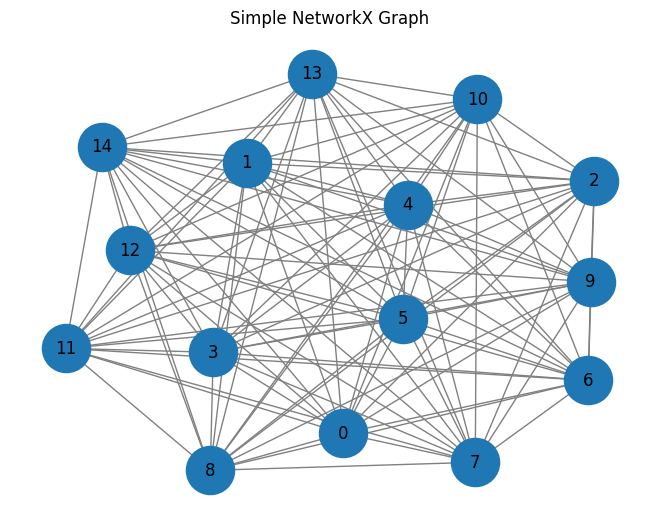

In [ ]:


graph = gnp_random_connected_graph(N,.1)


nx.draw(graph, with_labels=True, edge_color='gray', node_size=1200)
# , node_color='lightblue'
# 3. Display the plot
plt.title("Simple NetworkX Graph")
plt.show()

Steps:
generaate graph
generate W, stochastic adjacency matrix
place individuals onto graph (maybe move this step up once)

In [166]:
for node,attributes in graph.nodes(data=True):
    attributes['color'] = 'red'
    attributes['fitness'] = 1
    attributes['strategy'] = 'cooperate'

W = np.zeros((N,N))

# if directed, then W can be found from networkx stuff

In [173]:
# Make W stochastic, uniform
for node in graph.adj:
    for nb in graph.adj[node]:
        W[node][nb] = 1/graph.degree(node)

r = random.randint(0,N-1)


graph.nodes[r]['color'] = 'blue'
graph.nodes[r]['strategy'] = 'defect'

        


In [162]:

def update_rule():
    

    fitness_values = [graph.nodes[n]['fitness'] for n in range(N)]
    sum_fitness = sum(fitness_values)
    probs = [f/sum_fitness for f in fitness_values]

    selected_node = np.random.choice(graph.nodes, p=probs)


    death = np.random.choice(graph.nodes, p=W[selected_node])

    for key in graph.nodes[death].keys():
        graph.nodes[death][key] = graph.nodes[selected_node][key]
    
    return graph



In [163]:
def get_stats():

    strategies=[graph.nodes[n]['strategy'] for n in range(N)]

    num_coop = strategies.count('cooperate')
    num_def = strategies.count('defect')

    return num_coop, num_def




In [174]:
cooperators = []
defectors = []

#initialize
x,y = get_stats()
cooperators.append(x)
defectors.append(y)


for n in range(200):

    update_rule()
    x,y = get_stats()
    cooperators.append(x)
    defectors.append(y)

print(cooperators)
print(defectors)



[9, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 11, 11, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 9, 9, 10, 10, 11, 10, 10, 9, 9, 9, 9, 8, 8, 8, 9, 9, 10, 10, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 8, 8, 9, 9, 9, 9, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 10, 9, 9, 8, 8, 8, 8, 8, 7, 7, 6, 5, 5, 5, 5, 5, 4, 4, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 4, 3, 3, 3, 3, 3]
[6, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 4, 4, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 6, 6, 5, 5, 4, 5, 5, 6, 6, 6, 6, 7, 7, 7, 6, 6, 5, 5, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 